# Работа 2

Переформулировать схему для уравнения Лапласа для вектора неизвестных величин $ F = \{f\_{0,0}, f\_{1,0}, ..., f\_{0,1}, f\_{1,1}, ..., f\_{N-1,N-1} \} $ в виде СЛАУ:

$$
AF = b
$$

Подготовить хранение матрицы, решения и правой части для одного из методов библиотек `numpy` или `scipy` (см. ниже)

Решить (2) одним из следующих методов:

1. LU: `numpy.linalg.lu` или `numpy.linalg.solve`
2. GMRes: `scipy.sparse.linalg.gmres`

---

Замерить время установления решения с точностью $\varepsilon=0.001$ при $N=10; 100; 1000$


In [69]:
import time

import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

In [70]:
def BuildLaplaceSystem(N: int) -> tuple[sp.csr_array, np.ndarray]:
  """
  Построение СЛАУ для уравнения Лапласа на сетке N x N

  Args:
      N (int): размер сетки

  Returns:
      tuple[np.ndarray, np.ndarray]: матрица A и вектор b
  """
  total_points = N * N
  h = 1.0 / (N - 1)

  A = sp.lil_matrix((total_points, total_points))
  b = np.zeros(total_points)

  for i in range(N):
    for j in range(N):
      idx = i * N + j

      if i == 0 or i == N - 1 or j == 0 or j == N - 1:
        A[idx, idx] = 1

        if i == N - 1:
          b[idx] = j * h
        else:
          b[idx] = 0
      else:
        A[idx, idx] = -4 / (h**2)
        A[idx, idx - 1] = 1 / (h**2)
        A[idx, idx + 1] = 1 / (h**2)
        A[idx, idx - N] = 1 / (h**2)
        A[idx, idx + N] = 1 / (h**2)
        b[idx] = 0

  return A.tocsr(), b

In [71]:
def SolveLu(A: sp.csr_array, b: np.ndarray):
  """Решение методом LU-разложения"""

  start_time = time.time()
  x = spla.spsolve(A, b)
  end_time = time.time()
  return x, end_time - start_time


def SolveGMRes(A: sp.csr_array, b: np.ndarray, tol: float = 1e-3):
  """Решение методом GMRes"""

  start_time = time.time()
  x, info = spla.gmres(A, b, rtol=tol)
  end_time = time.time()

  if info > 0:
    print(f"Предупреждение: GMRes не сошелся за {info} итераций")
  elif info < 0:
    print(f"Ошибка в GMRes: код {info}")

  return x, end_time - start_time


In [72]:
def CreatePreconditioner(A, method="ilu"):
  """Создание предобуславливателя"""
  if method == "ilu":
    # ILU предобуславливатель
    M = spla.spilu(A.tocsc(), drop_tol=1e-4)

    def M_x(x):
      return M.solve(x)

    return spla.LinearOperator(A.shape, M_x)

  elif method == "diag":
    # Диагональный предобуславливатель (Jacobi)
    diag = A.diagonal()
    diag[diag == 0] = 1.0  # избегаем деления на 0

    def M_x(x):
      return x / diag

    return spla.LinearOperator(A.shape, M_x)
  else:
    return None


def SolveGMResOptimized(A, b):
  """Оптимизированное решение методом GMRes"""
  start_time = time.time()

  x0 = np.zeros_like(b)  # начальное приближение

  x, info = spla.gmres(
    A,
    b,
    x0=x0,
    M=CreatePreconditioner(A, method="diag"),
    callback=None,
  )

  end_time = time.time()

  if info > 0:
    print(f"Предупреждение: GMRes не сошелся за {info} итераций")
  elif info < 0:
    print(f"Ошибка в GMRes: код {info}")

  return x, end_time - start_time, info

In [73]:
# Измерение времени для разных размеров сетки
sizes = [10, 100]

results = {}

for N in sizes:
  print(f"\n=== Решение для N = {N} ===")
  print("Построение системы...")

  A, b = BuildLaplaceSystem(N)
  print(f"Размерность системы: {A.shape}")
  print(f"Количество ненулевых элементов: {A.nnz}")

  print("LU метод...")
  try:
    x_lu, time_lu = SolveLu(A, b)
    print(f"Время LU: {time_lu:.4f} сек")
  except Exception as e:
    print(f"LU метод не удался: {e}")
    x_lu, time_lu = None, float("inf")

  print("GMRes метод...")
  x_gmres, time_gmres, _ = SolveGMResOptimized(A, b)
  print(f"Время GMRes: {time_gmres:.4f} сек")

  results[N] = {
    "lu_time": time_lu,
    "gmres_time": time_gmres,
    "lu_solution": x_lu,
    "gmres_solution": x_gmres,
    "matrix": A,
    "rhs": b,
  }



=== Решение для N = 10 ===
Построение системы...
Размерность системы: (100, 100)
Количество ненулевых элементов: 356
LU метод...
Время LU: 0.0013 сек
GMRes метод...
Время GMRes: 0.0173 сек

=== Решение для N = 100 ===
Построение системы...
Размерность системы: (10000, 10000)
Количество ненулевых элементов: 48416
LU метод...
Время LU: 0.0806 сек
GMRes метод...
Время GMRes: 1.1794 сек


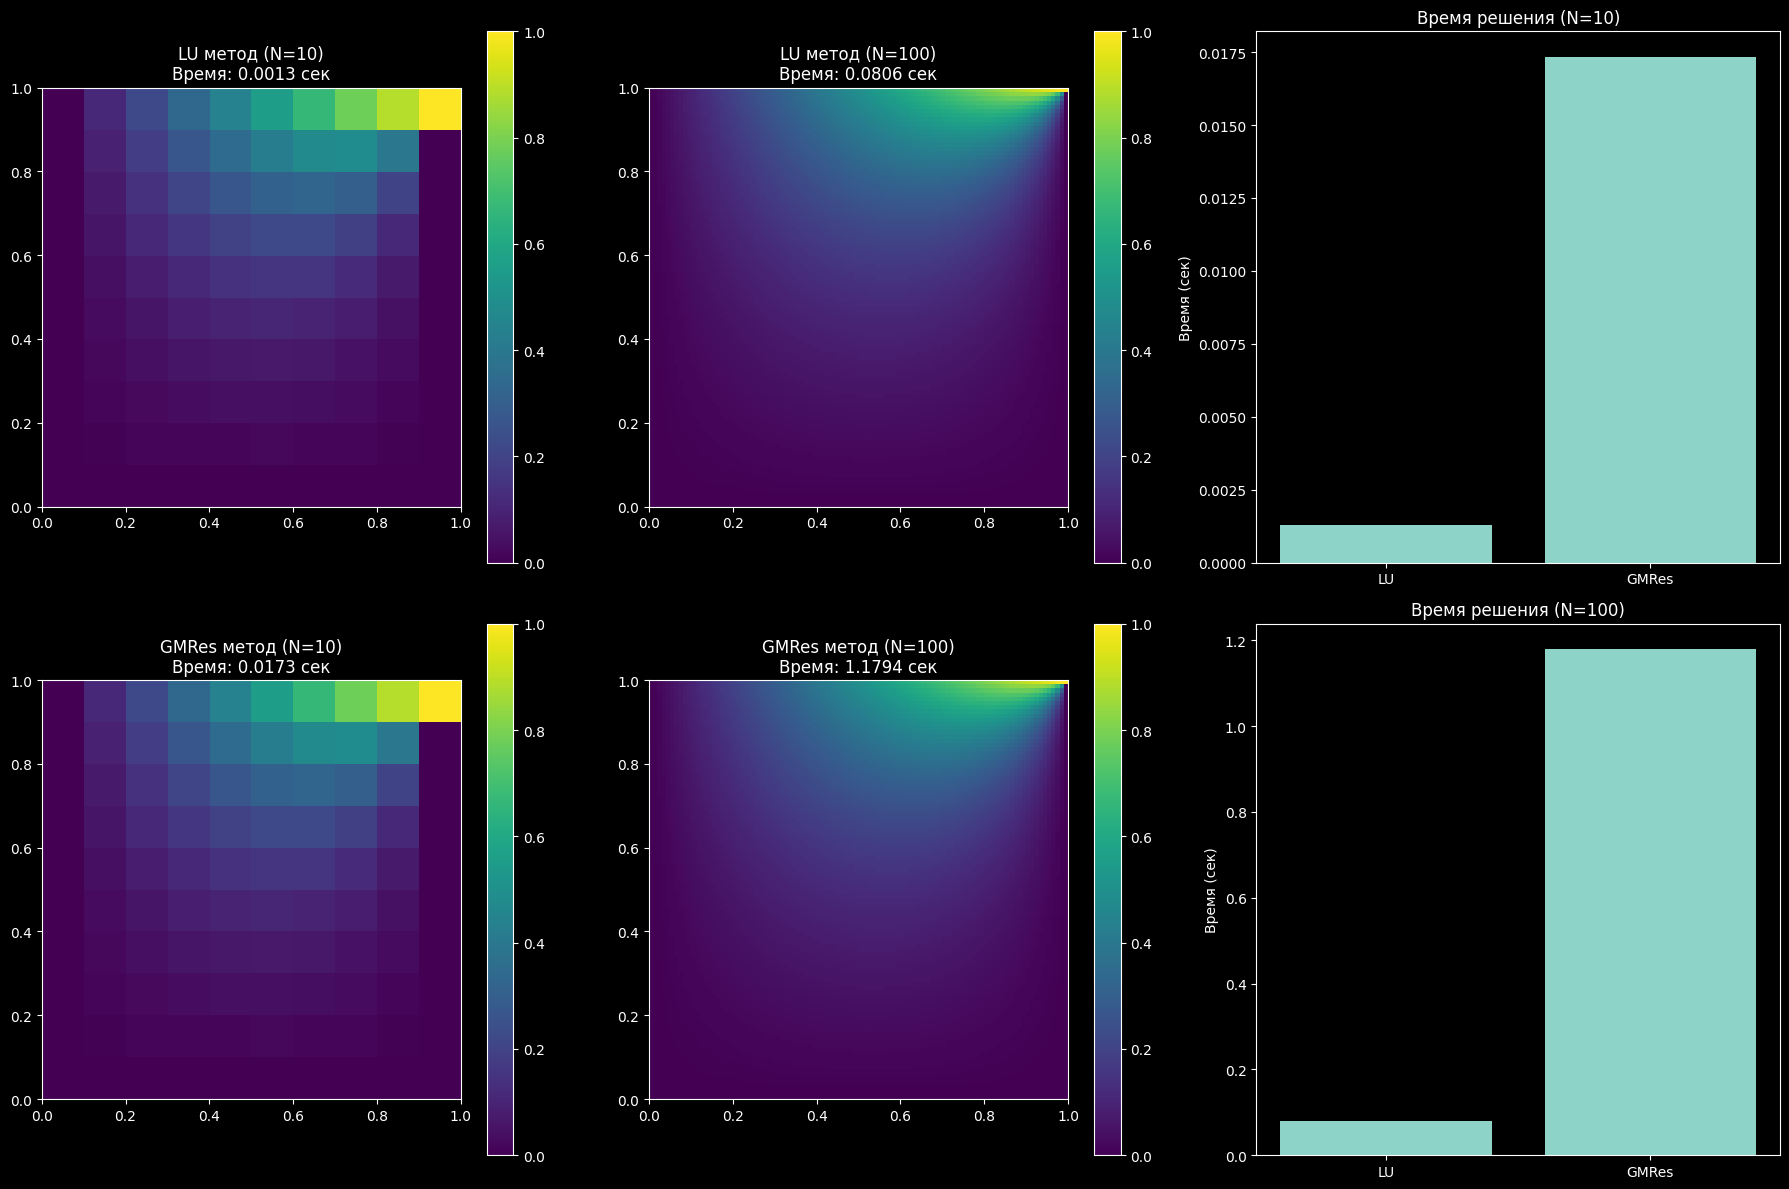

In [74]:
# визуализация результатов
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, N in enumerate(sizes):
  result = results[N]

  # Восстановление 2D формы
  if result["lu_solution"] is None:
    raise ValueError("Result of LU solution is None")

  f_lu = result["lu_solution"].reshape(N, N)
  f_gmres = result["gmres_solution"].reshape(N, N)

  # визуализация решений
  if result["lu_solution"] is not None:
    im1 = axes[0, idx].imshow(f_lu, extent=[0, 1, 0, 1], origin="lower", cmap="viridis")
    axes[0, idx].set_title(f"LU метод (N={N})\nВремя: {result['lu_time']:.4f} сек")
    plt.colorbar(im1, ax=axes[0, idx])

  im2 = axes[1, idx].imshow(f_gmres, extent=[0, 1, 0, 1], origin="lower", cmap="viridis")
  axes[1, idx].set_title(f"GMRes метод (N={N})\nВремя: {result['gmres_time']:.4f} сек")
  plt.colorbar(im2, ax=axes[1, idx])

# сравнение времени
axes[0, 2].bar(
  ["LU", "GMRes"], [results[sizes[0]]["lu_time"], results[sizes[0]]["gmres_time"]]
)
axes[0, 2].set_title("Время решения (N=10)")
axes[0, 2].set_ylabel("Время (сек)")

axes[1, 2].bar(
  ["LU", "GMRes"], [results[sizes[1]]["lu_time"], results[sizes[1]]["gmres_time"]]
)
axes[1, 2].set_title("Время решения (N=100)")
axes[1, 2].set_ylabel("Время (сек)")

plt.tight_layout()
plt.show()


=== Структура матрицы (N=10) ===


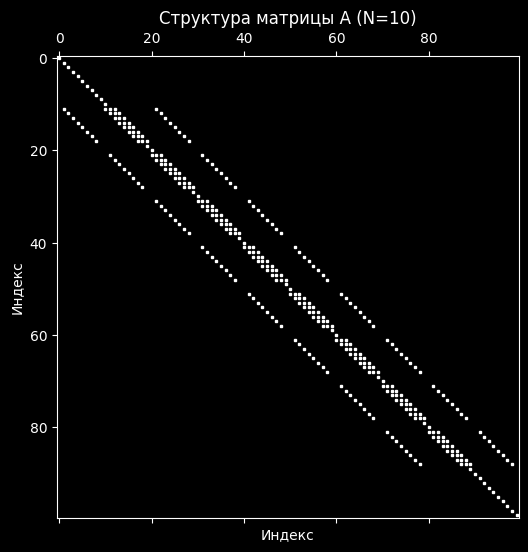

Размер матрицы для N=10: (100, 100)
Заполненность: 3.56%


In [75]:
print("\n=== Структура матрицы (N=10) ===")
A_small = results[10]["matrix"]
plt.figure(figsize=(8, 6))
plt.spy(A_small, markersize=2)
plt.title("Структура матрицы A (N=10)")
plt.xlabel("Индекс")
plt.ylabel("Индекс")
plt.show()

print(f"Размер матрицы для N=10: {A_small.shape}")
print(f"Заполненность: {A_small.nnz / (A_small.shape[0] * A_small.shape[1]) * 100:.2f}%")